# Calibration of the Z-axis in a laser scanning microscope

In this notebook, we present the procedure to calibrate the Z-axis scanner (e.g., piezo motor or varifocal lens) of a microscope. We used the calibration sample from Argolight. The reference patterns we used are the [3D crossing stairs](https://argolight.com/files/Argo-SIM/Argo-SIM-v1.1_User-guide.pdf) with axial step Δz = 0.5 µm.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

import brighteyes_ism.dataio.mcs as mcs
import brighteyes_ism.analysis.Tools_lib as tool
import brighteyes_ism.analysis.Graph_lib as gr

from skimage.filters import gaussian
from skimage.filters import threshold_otsu
from sklearn.cluster import KMeans

import os

## Data loading
In this case, the data are stored as an hdf5 file generated by the [BrightEyes-MCS](https://github.com/VicidominiLab/BrightEyes-MCS) software.

In [135]:
path = r'\\iitfsvge101.iit.local\mms\Data MMS server\Protocol\Calibration\Stairs_500nm\Argolight_Stairs_500nm_bis-22-04-2026-14-40-42.h5'

fullpath = os.path.join(path)

with h5py.File(fullpath, 'r') as file:
    data, meta = mcs.load(fullpath)
print('Loaded data: ' + fullpath)

data = tool.CropEdge(data, npx=10, edges='lrud', order = 'rzxytc')

print(data.shape)

Loaded data: \\iitfsvge101.iit.local\mms\Data MMS server\Protocol\Calibration\Stairs_500nm\Argolight_Stairs_500nm_bis-22-04-2026-14-40-42.h5
(1, 101, 401, 181, 1, 25)


To perform the acquisition, we used a 488 nm CW laser. The power is roughly 50 µW on the focal plane.<br>
The microscope is a custom ISM setup, equipped with a 100x/1.4 oil objective lens.<br>
The detector array size is 1.4 Airy Units.<br>
We print the metadata, to show the acquisition parameters.

In [136]:
meta.Print()

version       0.0.1
comment       
rangex        20.0
rangey        42.0
rangez        10.0
nbin          1
dt            50.0
nx            201
ny            421
nz            101
nrep          1
calib_x       22.242836
calib_y       22.775732
calib_z       1.675


The ISM data structure is (repetition, z, y, x, time, channel). <br>
Since we are not interested in having high-resolution, we keep only the spatial dimensions (z, y, x).

In [137]:
data = np.sum(data, axis = (0,4,5))

We crop the edges of the stack, because we are interested only in the stairway structures.

In [138]:
dset_raw = data[:, :, :]

We have a look at the z-stack.

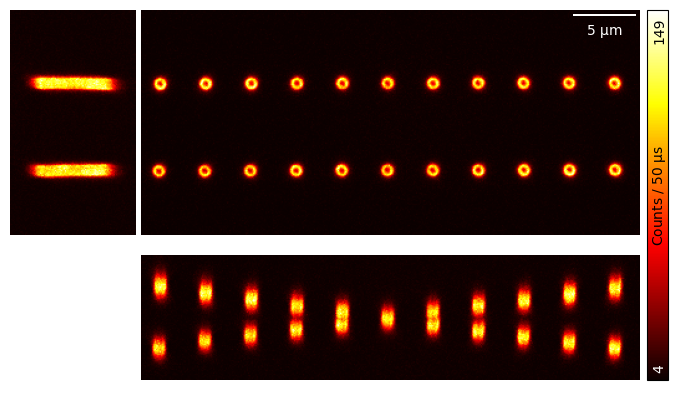

In [139]:
figsize = (7, 4.3)
dset_flip = np.swapaxes(dset_raw, 1, 2)
fig = gr.ShowStack(dset_flip, meta.dx, meta.dz, clabel = meta.pxdwelltime, projection = 'mip', figsize = figsize)

## Pre-processing

We want to measure only the center-of-mass of each step of the stairway.<br>
Thus, we sacrifice some resolution to denoise the dataset with a Gaussian filter.

In [140]:
dset = gaussian(dset_raw, sigma = 2)
dset /= dset.max()

We convert the z-stack (Z, Y, X) to a point cloud where each row contains the 3D coordinates and the corresponding intensity value.

In [141]:
point_cloud_matrix = tool.point_cloud_from_img(dset)

We remove the background with the Otsu method.

In [142]:
thresh = threshold_otsu(dset)
cloud = point_cloud_matrix[ point_cloud_matrix[:, -1] > thresh ]

We look at the thresholded scatter plot.

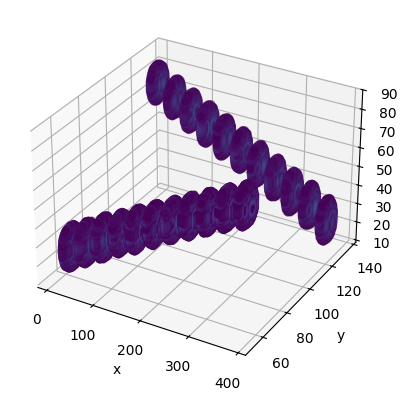

In [143]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(cloud[:,1], cloud[:,2], cloud[:,0], c = cloud[:,3])
ax.set_xlabel(r'x')
ax.set_ylabel(r'y')
ax.set_zlabel(r'z')
plt.savefig('Argolight_Z_clustering.png',dpi=300)

## Data clustering

We perform K-Means clustering to identify each step.

In [144]:
model = KMeans(n_clusters = 22, init = "k-means++", max_iter = 300, n_init = 10, random_state = 0)
y_clusters = model.fit_predict(cloud)

cm = model.cluster_centers_

We classify each stair using the y-coordinate.

In [145]:
cm.shape

(22, 4)

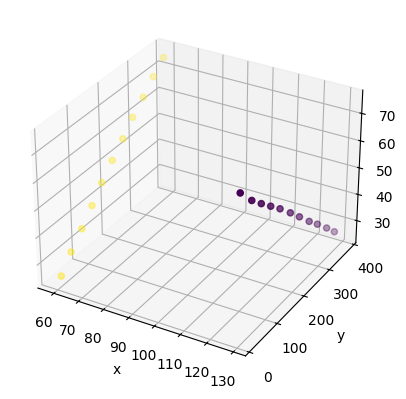

In [146]:
ym = cm[:, 2].mean()
cm_classes = cm[:, 2] < ym

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(cm[:, 2], cm[:, 1], cm[:, 0], c=cm_classes)
ax.set_xlabel(r'x')
ax.set_ylabel(r'y')
ax.set_zlabel(r'z')
plt.savefig('Argolight_Z_center_of_mass.pdf', dpi = 300)

## Calibration

We sort the z-coordinates of each class in ascending order.<br>
Additionally, we convert the units into Volts.

In [147]:
z_a = np.sort(cm[cm_classes == 0, 0])[:] * meta.dz / meta.calib_z  # Volt
z_b = np.sort(cm[cm_classes == 1, 0])[:] * meta.dz / meta.calib_z  # Volt

We generate an array with spacing Δz = 1 µm.

In [148]:
x = np.arange(len(z_a))*0.5 # micrometers

We fit each stair to a line. The slope is the desired calibration value.

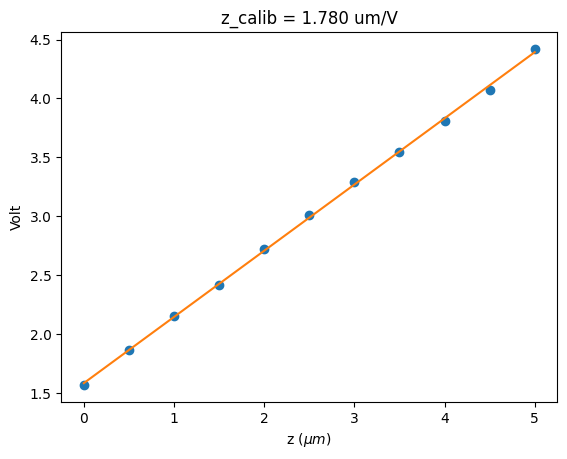

In [149]:
poly = np.polyfit(x, z_a, 1)

fit_a = np.poly1d(poly)

z_calib_a = 1 / poly[0] # um/Volt

plt.figure()
plt.plot( x,z_a, 'o' )
plt.plot( x,fit_a(x), '-' )
plt.xlabel(r'z $(\mu m)$' )
plt.ylabel(r'Volt' )
plt.title(f'z_calib = {z_calib_a:.3f} um/V' )
plt.savefig('Piezo_Z_calibration_z_a')
plt.savefig('Piezo_Z_calibration_z_a.pdf', dpi = 300)

We repeat the same process for the second stair. The two calibration values should match.

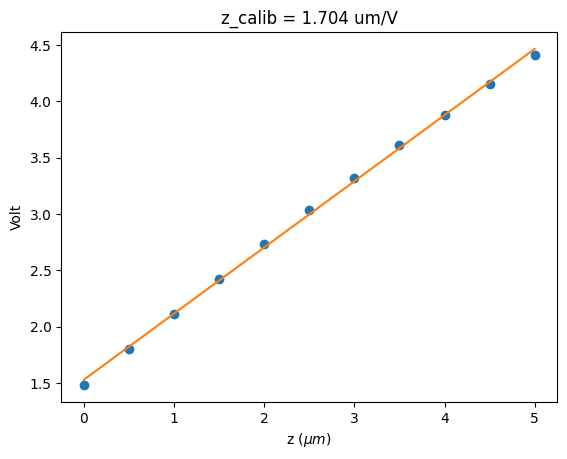

In [150]:
poly = np.polyfit(x, z_b, 1)

fit_b = np.poly1d(poly)

z_calib_b = 1 / poly[0] # um/Volt

plt.figure()
plt.plot( x,z_b, 'o' )
plt.plot( x,fit_b(x), '-' )
plt.xlabel(r'z $(\mu m)$' )
plt.ylabel(r'Volt' )
plt.title(f'z_calib = {z_calib_b:.3f} um/V' )
plt.savefig('Piezo_Z_calibration_z_b')
plt.savefig('Piezo_Z_calibration_z_b.pdf', dpi = 300)

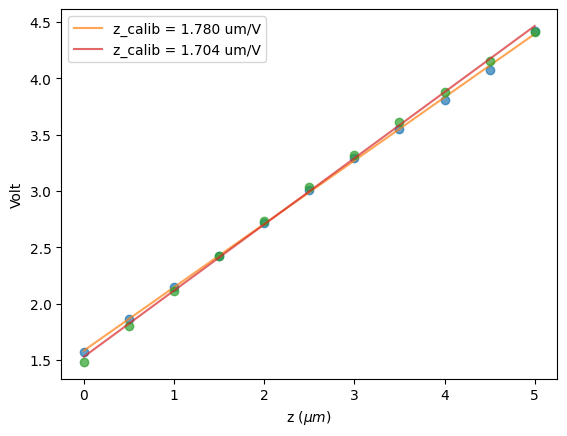

In [151]:
plt.figure()
plt.plot( x,z_a, 'o' , alpha = 0.7)
plt.plot( x,fit_a(x), '-', alpha = 0.7, label = f'z_calib = {z_calib_a:.3f} um/V')
plt.plot( x,z_b, 'o', alpha = 0.7)
plt.plot( x,fit_b(x), '-', alpha = 0.7 , label = f'z_calib = {z_calib_b:.3f} um/V' )
plt.xlabel(r'z $(\mu m)$' )
plt.ylabel(r'Volt' )
plt.legend( )
plt.savefig('Piezo_Z_calibration_z')
plt.savefig('Piezo_Z_calibration_z.pdf', dpi = 300)

We replot the images with the right scale for Z-axis:

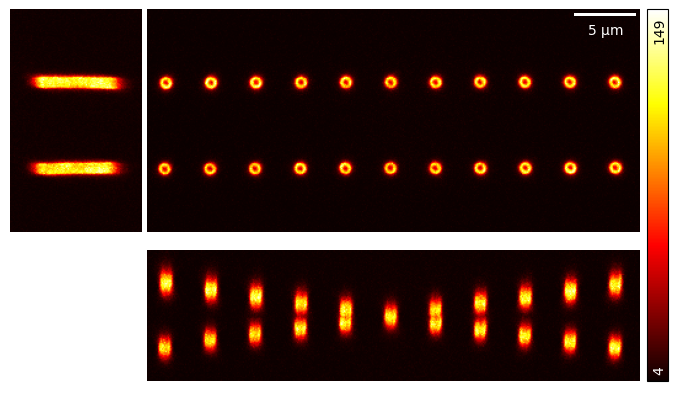

In [134]:
figsize = (7, 4.3)
dset_flip = np.swapaxes(dset_raw, 1, 2)
fig = gr.ShowStack(dset_flip, meta.dx, meta.dz/ meta.calib_z * z_calib_a, projection = 'mip', figsize = figsize)
plt.savefig('Argolight_Z_sum_image.pdf', dpi = 300)
plt.savefig('Argolight_Z_sum_image.png', dpi = 300)